In [1]:
from gensim.models import Word2Vec
import jieba

In [18]:
documents = []
with open("./cases/bert_finetune/reviews.txt", "r", encoding='utf-8') as file:
    for line in file:
        document = line.split('\t')[0]
        documents.append(document.replace('"', ' '))

docs = [jieba.lcut(document) for document in documents]

sg = 0
window_size = 5
vector_size = 100
epochs = 50
min_count = 3
seed = 42
workers = 1

model = Word2Vec(
    docs,
    vector_size=vector_size,
    window=window_size,
    sg=sg,
    min_count=min_count,
    workers=workers,
    seed=seed,
    epochs=epochs
)

In [19]:
vector = model.wv['房間']
print(vector)

[-2.7207422  -0.5864434  -0.05666691  0.7401427  -2.3149166   1.8443857
 -2.593433   -2.0060575   0.9059363  -2.4645889   1.1931098  -0.311801
 -2.2726467  -0.44821575 -0.85941005  1.964167   -0.13384071  2.2438154
 -0.7943997   0.05804618  0.5626107   0.06184999 -1.2898014  -2.6963007
  0.53030235  1.5118037   1.8791616  -0.5452938   2.11743    -0.03665269
 -0.49281865  0.21948633 -0.55776626 -0.5309228  -1.0374745   0.23444884
 -0.68774563  1.1330215   0.3848533  -2.0297365   1.266732    0.40725914
  0.12202542  0.12611221  1.4472054   0.92447096  1.0951799  -0.68561417
  0.2376765  -0.10167419 -1.1504341  -0.48954895  1.1776344  -0.74638206
  1.3563894  -0.0581481   0.21791947 -1.3809372   2.8120344  -1.1608903
 -2.4241416   0.02664403  2.115901    0.30008012 -0.98495084 -0.34450212
 -0.02682781  0.97594243  1.8318837  -1.297308    1.8295835  -0.70895374
  0.7970573  -1.2056389  -1.4343394  -0.03230915  0.81162864 -2.051556
 -0.1991514   1.6212851  -0.08713585  0.39567363  1.1747171

In [20]:
model.save('word2vec.model')

In [21]:
loaded_model = Word2Vec.load('word2vec.model')

In [22]:
loaded_model.wv.most_similar('浴室', topn=10)

[('淋浴房', 0.7075372338294983),
 ('衛生間', 0.6949584484100342),
 ('淋浴', 0.6522138714790344),
 ('水壓', 0.6504632234573364),
 ('浴缸', 0.6044964790344238),
 ('龍頭', 0.5943660736083984),
 ('花灑', 0.5889952182769775),
 ('水量', 0.5840455293655396),
 ('水龍頭', 0.5685974955558777),
 ('洗澡水', 0.5615367293357849)]

In [23]:
loaded_model.wv.similarity('房間', '床')

np.float32(0.4567668)

訓練第1個 epoch
Epoch 01 | alpha 0.02500->0.02451 | Loss 1329173.125
訓練第2個 epoch
Epoch 02 | alpha 0.02451->0.02402 | Loss 1096345.375
訓練第3個 epoch
Epoch 03 | alpha 0.02402->0.02353 | Loss 1013798.5625
訓練第4個 epoch
Epoch 04 | alpha 0.02353->0.02304 | Loss 960308.9375
訓練第5個 epoch
Epoch 05 | alpha 0.02304->0.02255 | Loss 923856.0625
訓練第6個 epoch
Epoch 06 | alpha 0.02255->0.02206 | Loss 895398.3125
訓練第7個 epoch
Epoch 07 | alpha 0.02206->0.02157 | Loss 871353.375
訓練第8個 epoch
Epoch 08 | alpha 0.02157->0.02108 | Loss 852415.6875
訓練第9個 epoch
Epoch 09 | alpha 0.02108->0.02059 | Loss 833174.8125
訓練第10個 epoch
Epoch 10 | alpha 0.02059->0.02010 | Loss 818425.0625
訓練第11個 epoch
Epoch 11 | alpha 0.02010->0.01961 | Loss 804728.4375
訓練第12個 epoch
Epoch 12 | alpha 0.01961->0.01912 | Loss 795037.5
訓練第13個 epoch
Epoch 13 | alpha 0.01912->0.01863 | Loss 784264.125
訓練第14個 epoch
Epoch 14 | alpha 0.01863->0.01814 | Loss 774517.4375
訓練第15個 epoch
Epoch 15 | alpha 0.01814->0.01765 | Loss 765404.25
訓練第16個 epoch
Epoch 16 | a

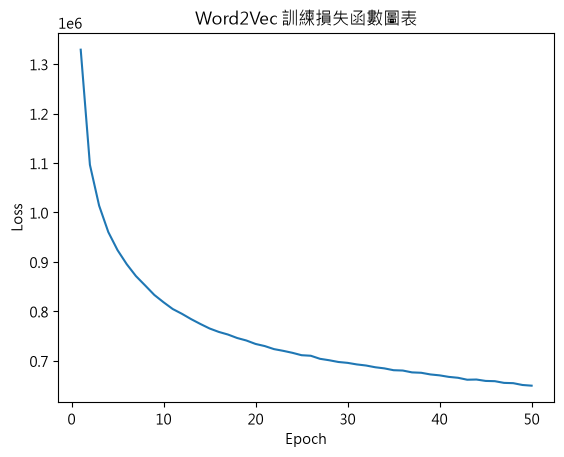

In [24]:
from gensim.models import Word2Vec
import jieba
import matplotlib.pyplot as plt
import matplotlib
import random
matplotlib.rc('font', family='Microsoft JhengHei')

# 讀取文本
documents = []
with open("./cases/bert_finetune/reviews.txt", "r", encoding="utf-8") as file:
    for line in file:
        document = line.split("\t")[0]
        documents.append(document.replace('"', ''))

# 使用 jieba 進行斷詞
docs = [jieba.lcut(document) for document in documents]

# 初始化模型，並啟用損失計算
model_new = Word2Vec(
    vector_size=100,
    window=5,
    sg=0,
    min_count=3,
    workers=1,
    seed=42
)

model_new.build_vocab(docs)
num_epochs = 50
start_alpha = 0.025
end_alpha = 0.0005
alpha_delta = (start_alpha - end_alpha) / num_epochs
losses = []

for epoch in range(num_epochs):
    random.shuffle(docs)
    print("=" * 50)
    print(f"訓練第{epoch+1}個 epoch")
    a0 = start_alpha - epoch * alpha_delta
    a1 = start_alpha - (epoch + 1) * alpha_delta

    model_new.train(
        docs,
        total_examples=model_new.corpus_count,
        epochs=1,
        start_alpha=a0,
        end_alpha=a1,
        compute_loss=True
    )

    loss = model_new.get_latest_training_loss()
    losses.append(loss)

    print(f"Epoch {epoch+1:02d} | alpha {a0:.5f}->{a1:.5f} | Loss {loss}")

plt.plot(range(1, num_epochs+1), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Word2Vec 訓練損失函數圖表')
plt.show()